In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

# 모델 성능 평가: Precision, Recall, F1 Score, ROC Curve, AUC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/preprocessing_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temp_OXid          14816 non-null  float64
 1   ppm                14816 non-null  float64
 2   type               14816 non-null  object 
 3   UV_type            14816 non-null  object 
 4   thickness          14816 non-null  float64
 5   resist_target      14816 non-null  float64
 6   temp_HMDS_bake     14816 non-null  float64
 7   kperna             14816 non-null  float64
 8   Line_CD            14816 non-null  float64
 9   Energy_Exposure    14816 non-null  float64
 10  Source_Power       14816 non-null  float64
 11  Temp_Etching       14816 non-null  float64
 12  etching_velo       14816 non-null  float64
 13  RTA_Temp           14816 non-null  int64  
 14  Temp_implantation  14816 non-null  float64
 15  input_Energy       14816 non-null  float64
 16  max_flux           148

In [3]:
# 다수 클래스 찾기
majority_class = df[df['y_label'] == 0]
minority_class = df[df['y_label'] == 1]

# 다수 클래스를 소수 클래스 개수만큼 샘플링
majority_downsampled = resample(majority_class, 
                                replace=False,  # 복원 샘플링 X
                                n_samples=len(minority_class),  # 소수 클래스 개수에 맞춤
                                random_state=42)

# 두 클래스를 합쳐서 새로운 데이터셋 생성
df_resampled = pd.concat([majority_downsampled, minority_class])
df_resampled.reset_index(inplace = True)

In [4]:
object_x = df_resampled.select_dtypes('object')
numeric_x = df_resampled.select_dtypes(exclude = 'object')
numeric_x.drop('y_label', axis = 1, inplace = True)

In [5]:
dummies = pd.get_dummies(object_x)

std = StandardScaler()
scaled_df = std.fit_transform(numeric_x)
scaled_df = pd.DataFrame(scaled_df, columns = numeric_x.columns)

df_scale_dummies_x = pd.concat([scaled_df, dummies], axis = 1)
df_scale_dummies_x.head()

,index,Temp_OXid,ppm,thickness,resist_target,temp_HMDS_bake,kperna,Line_CD,Energy_Exposure,Source_Power,...,etching_velo,RTA_Temp,Temp_implantation,input_Energy,max_flux,type_dry,type_wet,UV_type_G,UV_type_H,UV_type_I
0,1.381225,-0.495241,-0.189517,-0.506862,-0.387575,0.267062,0.139509,-0.421313,-0.961801,-0.559626,...,-0.376779,0.889532,0.859680,-0.584207,-0.164403,1,0,0,1,0
1,1.413291,-1.049026,-1.263372,0.092006,0.080833,-0.703170,-0.168690,-1.046809,0.257540,0.189945,...,1.275358,0.469481,0.348029,0.348691,-0.836789,1,0,1,0,0
2,-0.734613,0.310587,-0.759041,0.038773,-0.903049,0.660742,2.330225,0.649131,-0.360081,0.179280,...,-0.057458,-1.210725,-0.957044,-1.416179,-0.832534,1,0,0,0,1
3,-0.963283,0.668697,-0.035757,-1.486343,0.782325,-1.320000,1.775646,0.310750,0.081349,-2.282724,...,0.477057,0.049429,-0.900328,-1.931938,-0.836789,0,1,0,0,1
4,-0.839235,-1.029459,-1.232620,-0.140887,0.486488,0.674384,-2.701849,-1.339437,0.334504,-0.148276,...,1.157348,0.049429,0.240631,0.525132,0.682463,1,0,1,0,0


In [6]:
df_y = df_resampled['y_label']
df_y.head()

0    0
1    0
2    0
3    0
4    0
Name: y_label, dtype: int64

In [7]:
train_x, test_x,  train_y, test_y = train_test_split(df_scale_dummies_x, df_y, test_size = 0.3, random_state=1986)

In [8]:

param = {
    'hidden_layer_sizes' : [(50,),(50,50), (100,), (100,100), (500,)],
    'activation' : ['tanh'],
    'batch_size' : [100,200,300,400,500],
    'learning_rate_init' : [0.01]
}

grid_search = GridSearchCV(MLPClassifier(max_iter=500, random_state=42, solver='adam', early_stopping=True, verbose= 2), # max_iter 증가, early_stopping 추가
                           param_grid = param, verbose=10, n_jobs=2) # verbose 증가, n_jobs 변경
grid_search.fit(train_x, train_y)

print(grid_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Iteration 1, loss = 0.53381307
Validation score: 0.854305
Iteration 2, loss = 0.37234720
Validation score: 0.887417
Iteration 3, loss = 0.30522774
Validation score: 0.874172
Iteration 4, loss = 0.25704111
Validation score: 0.927152
Iteration 5, loss = 0.22049817
Validation score: 0.940397
Iteration 6, loss = 0.19635041
Validation score: 0.947020
Iteration 7, loss = 0.15691985
Validation score: 0.973510
Iteration 8, loss = 0.13089880
Validation score: 0.966887
Iteration 9, loss = 0.11338218
Validation score: 0.973510
Iteration 10, loss = 0.09953050
Validation score: 0.973510
Iteration 11, loss = 0.09064978
Validation score: 0.986755
Iteration 12, loss = 0.09459767
Validation score: 0.986755
Iteration 13, loss = 0.06690076
Validation score: 0.980132
Iteration 14, loss = 0.06751911
Validation score: 0.973510
Iteration 15, loss = 0.05911491
Validation score: 0.986755
Iteration 16, loss = 0.04649555
Validation score: 0.986755
Ite

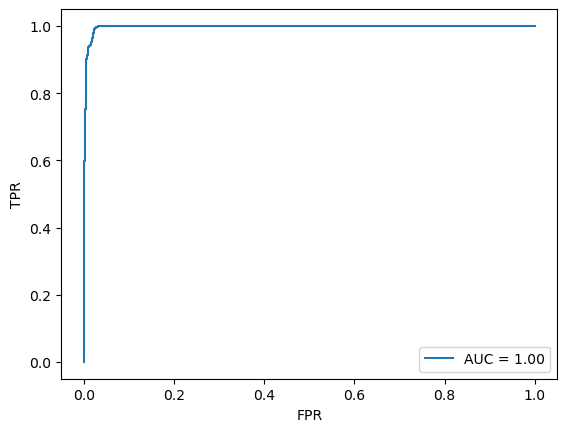

[[736  21]
 [  2 746]]


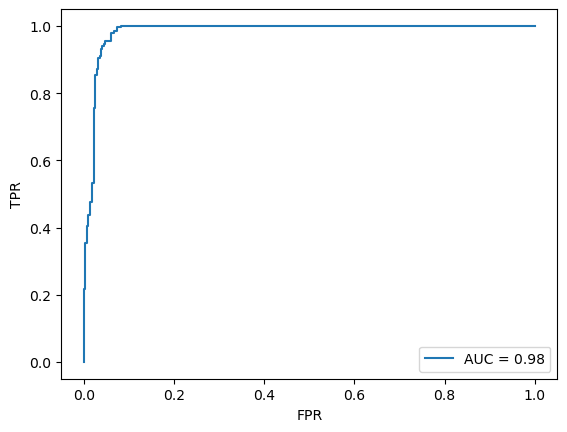

[[295  23]
 [  1 326]]
             NN_train   NN_test
Accuracy     0.984718  0.962791
Precision    0.972621  0.934097
Recall       0.997326  0.996942
F1_score     0.984818  0.964497
Specificity  0.972259  0.927673


In [9]:
def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR")
    plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    print(cm)
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])

best_model = grid_search.best_estimator_

y_pred_train = best_model.predict(train_x)
y_proba_train = best_model.predict_proba(train_x)[:, 1]
y_pred_test = best_model.predict(test_x)
y_proba_test = best_model.predict_proba(test_x)[:, 1]


metric_df_first = pd.DataFrame()
metric_list_train = print_metric(train_y, y_pred_train,y_proba_train, "NN_train")
metric_list_test = print_metric(test_y, y_pred_test, y_proba_test, "NN_test")

metric_df_first['NN_train'] = metric_list_train
metric_df_first['NN_test'] = metric_list_test

print(metric_df_first)